In [1]:
# %%
# Jupyter가 아닌 환경에서도 display()가 동작하도록 하는 shim
try:
    from IPython.display import display
except Exception:
    display = print

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("yfinance:", yf.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

yfinance: 1.5.2 | pandas: 3.0.3 | numpy: 1.26.4


In [3]:
TICKER     = "^GSPC"        # S&P500. DJIA=^DJI, NASDAQ=^IXIC, Russell2000=^RUT
                            # 개별 종목도 가능: "AAPL", "MSFT" 등
START_DATE = "2005-01-01"
END_DATE   = "2025-01-01"
HORIZON    = 1              # 며칠 뒤를 예측할지 (1 = 다음 거래일)

LOGRET       = True         # [F] True=로그 수익률 / False=단순 수익률
USE_SNAPSHOT = True         # [C] 스냅샷 캐시 사용
SNAPSHOT_PATH = f"raw_snapshot_{TICKER.replace('^','')}.csv"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("종목:", TICKER, "| 기간:", START_DATE, "~", END_DATE)
print("예측 시계:", HORIZON, "일 뒤 | 수익률 변환:", "로그" if LOGRET else "단순")
print("스냅샷 경로:", SNAPSHOT_PATH)

종목: ^GSPC | 기간: 2005-01-01 ~ 2025-01-01
예측 시계: 1 일 뒤 | 수익률 변환: 로그
스냅샷 경로: raw_snapshot_GSPC.csv


In [4]:
def download_raw(ticker, start, end):
    # yfinance 다운로드 (버전 호환 처리 포함)
    try:
        df = yf.download(
            tickers=ticker, start=start, end=end,
            interval="1d", auto_adjust=True, actions=False,
            progress=False, multi_level_index=False,
        )
    except TypeError:                       # 구버전엔 multi_level_index 인자가 없음
        df = yf.download(
            tickers=ticker, start=start, end=end,
            interval="1d", auto_adjust=True, actions=False, progress=False,
        )
    # fallback: 그래도 MultiIndex면 상위 레벨만 남김 (단일 티커라 하위 레벨엔 정보 없음)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df


if USE_SNAPSHOT and os.path.exists(SNAPSHOT_PATH):
    raw_data = pd.read_csv(SNAPSHOT_PATH, index_col=0, parse_dates=True)
    source = "스냅샷 로드"
else:
    raw_data = download_raw(TICKER, START_DATE, END_DATE)
    if raw_data.empty:
        raise ValueError("데이터를 불러오지 못함. 티커/기간/네트워크 확인 필요.")
    raw_data.to_csv(SNAPSHOT_PATH)
    source = "새로 다운로드 후 저장"

if raw_data.empty:
    raise ValueError("데이터가 비어 있음.")

print(f"{source}:{raw_data.shape}  ({SNAPSHOT_PATH})")
print("컬럼:", list(raw_data.columns))
raw_data.head()

스냅샷 로드:(5033, 5)  (raw_snapshot_GSPC.csv)
컬럼: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2005-01-03,1202.079956,1217.800049,1200.319946,1211.920044,1510800000
2005-01-04,1188.050049,1205.839966,1185.390015,1202.079956,1721000000
2005-01-05,1183.739990,1192.729980,1183.719971,1188.050049,1738900000
2005-01-06,1187.890015,1191.630005,1183.270020,1183.739990,1569100000
2005-01-07,1186.189941,1192.199951,1182.160034,1187.890015,1477900000


In [5]:
required_columns = ["Open", "High", "Low", "Close", "Volume"]

missing_cols = [c for c in required_columns if c not in raw_data.columns]
if missing_cols:
    raise KeyError(f"필수 컬럼 누락:{missing_cols} / 실제 컬럼:{list(raw_data.columns)}")

data = raw_data[required_columns].copy()

# 날짜 인덱스 정합성 점검
data.index = pd.to_datetime(data.index)
data.index.name = "Date"
data = data.sort_index()

print("날짜 오름차순 여부:", data.index.is_monotonic_increasing)
print("중복 날짜 수:", int(data.index.duplicated().sum()))
print("첫 날짜:", data.index.min().date(), "| 마지막 날짜:", data.index.max().date())
print("\n변수별 자료형"); print(data.dtypes)
print("\n변수별 결측치 수"); print(data.isnull().sum())
data.head()

날짜 오름차순 여부: True
중복 날짜 수: 0
첫 날짜: 2005-01-03 | 마지막 날짜: 2024-12-31

변수별 자료형
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

변수별 결측치 수
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1510800000
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1721000000
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1738900000
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1569100000
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1477900000


In [6]:
invalid_price = (data[["Open", "High", "Low", "Close"]] <= 0).any(axis=1)

invalid_ohlc = (
    (data["High"] < data["Low"])
    | (data["High"] < data["Open"]) | (data["High"] < data["Close"])
    | (data["Low"]  > data["Open"]) | (data["Low"]  > data["Close"])
)

# [D] 거래량: 음수뿐 아니라 0·결측도 잡는다
invalid_volume = (data["Volume"] <= 0) | data["Volume"].isna()

print("가격이 0 이하인 행 수:", int(invalid_price.sum()))
print("OHLC 관계가 이상한 행 수:", int(invalid_ohlc.sum()))
print("거래량이 0 이하/결측인 행 수:", int(invalid_volume.sum()))

bad_rows = invalid_price | invalid_ohlc | invalid_volume
print("\n이상 행 총계:", int(bad_rows.sum()), "/", len(data))

if bad_rows.any():
    print("\n[예시] 이상 행 상위 5개:")
    display(data[bad_rows].head())

    before = len(data)
    data = data[~bad_rows].copy()
    print(f"\n제거:{before} ->{len(data)}  ({before - len(data)}행)")
else:
    print("→ 제거할 행 없음")

가격이 0 이하인 행 수: 0
OHLC 관계가 이상한 행 수: 0
거래량이 0 이하/결측인 행 수: 1

이상 행 총계: 1 / 5033

[예시] 이상 행 상위 5개:


,Open,High,Low,Close,Volume
Date,,,,,
2023-05-24,4132.959961,4132.959961,4103.979980,4115.240234,0



제거:5033 ->5032  (1행)


In [7]:
feature_data = data.copy()
C = feature_data["Close"]

if LOGRET:
    # 1일 / 다기간 로그 수익률
    feature_data["Return_1d"] = np.log(C / C.shift(1))
    for w in [5, 10, 20, 60]:
        feature_data[f"Return_{w}d"] = np.log(C / C.shift(w))
    # 갭(밤사이) · 장중
    feature_data["Gap_Return"]      = np.log(feature_data["Open"] / C.shift(1))
    feature_data["Intraday_Return"] = np.log(C / feature_data["Open"])
else:
    feature_data["Return_1d"] = C.pct_change(fill_method=None)
    for w in [5, 10, 20, 60]:
        feature_data[f"Return_{w}d"] = C.pct_change(periods=w, fill_method=None)
    feature_data["Gap_Return"]      = feature_data["Open"] / C.shift(1) - 1
    feature_data["Intraday_Return"] = C / feature_data["Open"] - 1

print("변환:", "로그 수익률" if LOGRET else "단순 수익률")
feature_data[["Close", "Return_1d", "Return_5d", "Return_20d",
              "Gap_Return", "Intraday_Return"]].head(8)

변환: 로그 수익률


,Close,Return_1d,Return_5d,Return_20d,Gap_Return,Intraday_Return
Date,,,,,,
2005-01-03,1202.079956,NaN,NaN,NaN,NaN,-0.008153
2005-01-04,1188.050049,-0.011740,NaN,NaN,0.000000,-0.011740
2005-01-05,1183.739990,-0.003634,NaN,NaN,0.000000,-0.003634
2005-01-06,1187.890015,0.003500,NaN,NaN,0.000000,0.003500
2005-01-07,1186.189941,-0.001432,NaN,NaN,0.000000,-0.001432
2005-01-10,1190.250000,0.003417,-0.009890,NaN,0.000000,0.003417
2005-01-11,1182.989990,-0.006118,-0.004268,NaN,0.000000,-0.006118
2005-01-12,1187.699951,0.003973,0.003340,NaN,0.000000,0.003973


In [8]:
# [검증] 로그 수익률이면 다기간 수익률 = 일간 수익률의 합 (가법성)
if LOGRET:
    lhs = feature_data["Return_20d"]
    rhs = feature_data["Return_1d"].rolling(20).sum()
    gap = (lhs - rhs).abs().max()
    print(f"가법성 검증 |Return_20d - sum(Return_1d, 20)| 최대오차:{gap:.2e}")
    print("→ 부동소수점 오차 수준이면 정상")
else:
    print("단순 수익률 모드 — 가법성은 성립하지 않음 (참고용)")

print("\n로그 vs 단순 비교 (꼬리 구간):")
comp = pd.DataFrame({"실제 하락률": [-0.05, -0.10, -0.20, -0.30]})
comp["단순 수익률"] = comp["실제 하락률"]
comp["로그 수익률"] = np.log(1 + comp["실제 하락률"])
display(comp)

가법성 검증 |Return_20d - sum(Return_1d, 20)| 최대오차:9.37e-16
→ 부동소수점 오차 수준이면 정상

로그 vs 단순 비교 (꼬리 구간):


,실제 하락률,단순 수익률,로그 수익률
0,-0.050000,-0.050000,-0.051293
1,-0.100000,-0.100000,-0.105361
2,-0.200000,-0.200000,-0.223144
3,-0.300000,-0.300000,-0.356675


In [9]:
for lag in [1, 2, 3, 5]:
    feature_data[f"ret_lag{lag}"] = feature_data["Return_1d"].shift(lag)

feature_data[["Return_1d", "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5"]].head(8)

,Return_1d,ret_lag1,ret_lag2,ret_lag3,ret_lag5
Date,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN
2005-01-04,-0.011740,NaN,NaN,NaN,NaN
2005-01-05,-0.003634,-0.011740,NaN,NaN,NaN
2005-01-06,0.003500,-0.003634,-0.011740,NaN,NaN
2005-01-07,-0.001432,0.003500,-0.003634,-0.011740,NaN
2005-01-10,0.003417,-0.001432,0.003500,-0.003634,NaN
2005-01-11,-0.006118,0.003417,-0.001432,0.003500,-0.011740
2005-01-12,0.003973,-0.006118,0.003417,-0.001432,-0.003634


In [10]:
feature_data["High_Low_Range"] = (
    (feature_data["High"] - feature_data["Low"]) / feature_data["Close"].replace(0, np.nan)
)

daily_range = (feature_data["High"] - feature_data["Low"]).replace(0, np.nan)
feature_data["Close_Location"] = (feature_data["Close"] - feature_data["Low"]) / daily_range

feature_data[["High", "Low", "Close", "High_Low_Range", "Close_Location"]].head()

,High,Low,Close,High_Low_Range,Close_Location
Date,,,,,
2005-01-03,1217.800049,1200.319946,1202.079956,0.014542,0.100686
2005-01-04,1205.839966,1185.390015,1188.050049,0.017213,0.130075
2005-01-05,1192.729980,1183.719971,1183.739990,0.007611,0.002222
2005-01-06,1191.630005,1183.270020,1187.890015,0.007038,0.552632
2005-01-07,1192.199951,1182.160034,1186.189941,0.008464,0.401389


In [11]:
for w in [5, 10, 20, 60]:
    feature_data[f"SMA_{w}"] = (
        feature_data["Close"].rolling(window=w, min_periods=w).mean()
    )
    # 해석: 현재가가 SMA 대비 몇 % 위/아래인가
    feature_data[f"Close_to_SMA_{w}"] = feature_data["Close"] / feature_data[f"SMA_{w}"] - 1

feature_data[["Close", "Close_to_SMA_5", "Close_to_SMA_10",
              "Close_to_SMA_20", "Close_to_SMA_60"]].head(65).tail(8)

,Close,Close_to_SMA_5,Close_to_SMA_10,Close_to_SMA_20,Close_to_SMA_60
Date,,,,,
2005-03-28,1174.280029,-0.000395,-0.008731,-0.019963,NaN
2005-03-29,1165.359985,-0.004867,-0.012805,-0.025853,NaN
2005-03-30,1181.410034,0.007170,0.002178,-0.011238,-0.008998
2005-03-31,1180.589966,0.005089,0.002119,-0.010703,-0.009389
2005-04-01,1172.920044,-0.001695,-0.002928,-0.015582,-0.015616
2005-04-04,1176.119995,0.000715,0.000943,-0.010987,-0.012825
2005-04-05,1181.390015,0.002464,0.005633,-0.004717,-0.008312
2005-04-06,1184.069946,0.004285,0.006854,-0.000972,-0.006032


In [12]:
for w in [5, 10, 20, 60]:
    feature_data[f"Volatility_{w}"] = (
        feature_data["Return_1d"].rolling(window=w, min_periods=w).std()
    )

vol_mean = feature_data["Volume"].rolling(20, min_periods=20).mean()
vol_std  = feature_data["Volume"].rolling(20, min_periods=20).std().replace(0, np.nan)
feature_data["Volume_Z_20"] = (feature_data["Volume"] - vol_mean) / vol_std

feature_data[["Volatility_5", "Volatility_20", "Volatility_60",
              "Volume_Z_20"]].head(65).tail(5)

,Volatility_5,Volatility_20,Volatility_60,Volume_Z_20
Date,,,,
2005-03-31,0.007797,0.006480,0.006441,1.417696
2005-04-01,0.008571,0.006574,0.006318,1.141930
2005-04-04,0.008590,0.006125,0.006313,0.777699
2005-04-05,0.007419,0.006211,0.006324,0.049893
2005-04-06,0.004316,0.006234,0.006328,-0.246883


In [13]:
feature_data["Target_Next_Return"] = (
    np.log(feature_data["Close"].shift(-HORIZON) / feature_data["Close"])
    if LOGRET else
    feature_data["Close"].shift(-HORIZON) / feature_data["Close"] - 1
)

# [B] NaN을 0(하락)으로 삼키지 않도록 명시적으로 보존
feature_data["y_updown"] = np.where(
    feature_data["Target_Next_Return"].isna(),
    np.nan,
    (feature_data["Target_Next_Return"] > 0).astype(float),
)

# 검증: 꼬리 HORIZON행이 NaN으로 남아 있어야 정상
tail_na = feature_data["y_updown"].tail(HORIZON).isna().all()
print(f"[B 검증] 마지막{HORIZON}행이 NaN인가:{tail_na}  (True여야 정상)")
print("y_updown 결측 수:", int(feature_data['y_updown'].isna().sum()))

print("\n※ 아래 분포는 dropna 이전 값이라 참고용. 실제 학습 표본 분포는 §13에서 확인.")
feature_data[["Close", "Return_1d", "Target_Next_Return", "y_updown"]].tail(3)

[B 검증] 마지막1행이 NaN인가:True  (True여야 정상)
y_updown 결측 수: 1

※ 아래 분포는 dropna 이전 값이라 참고용. 실제 학습 표본 분포는 §13에서 확인.


,Close,Return_1d,Target_Next_Return,y_updown
Date,,,,
2024-12-27,5970.839844,-0.011117,-0.010760,0.000000
2024-12-30,5906.939941,-0.010760,-0.004294,0.000000
2024-12-31,5881.629883,-0.004294,NaN,NaN


In [14]:
feature_columns = [
    # 수익률 계열
    "Return_1d", "Return_5d", "Return_10d", "Return_20d", "Return_60d",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5",
    # 일중 구조
    "Gap_Return", "Intraday_Return", "High_Low_Range", "Close_Location",
    # 이동평균 괴리율
    "Close_to_SMA_5", "Close_to_SMA_10", "Close_to_SMA_20", "Close_to_SMA_60",
    # 변동성 · 거래량
    "Volatility_5", "Volatility_10", "Volatility_20", "Volatility_60",
    "Volume_Z_20",
]
target_reg = "Target_Next_Return"
target_cls = "y_updown"

model_data = feature_data[feature_columns + [target_reg, target_cls]].copy()
print("독립변수 개수:", len(feature_columns))
print("전체 데이터 크기:", model_data.shape)
model_data.head()

독립변수 개수: 22
전체 데이터 크기: (5032, 24)


,Return_1d,Return_5d,Return_10d,Return_20d,Return_60d,ret_lag1,ret_lag2,ret_lag3,ret_lag5,Gap_Return,Intraday_Return,High_Low_Range,Close_Location,Close_to_SMA_5,Close_to_SMA_10,Close_to_SMA_20,Close_to_SMA_60,Volatility_5,Volatility_10,Volatility_20,Volatility_60,Volume_Z_20,Target_Next_Return,y_updown
Date,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008153,0.014542,0.100686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011740,0.000000
2005-01-04,-0.011740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-0.011740,0.017213,0.130075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003634,0.000000
2005-01-05,-0.003634,NaN,NaN,NaN,NaN,-0.011740,NaN,NaN,NaN,0.000000,-0.003634,0.007611,0.002222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003500,1.000000
2005-01-06,0.003500,NaN,NaN,NaN,NaN,-0.003634,-0.011740,NaN,NaN,0.000000,0.003500,0.007038,0.552632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001432,0.000000
2005-01-07,-0.001432,NaN,NaN,NaN,NaN,0.003500,-0.003634,-0.011740,NaN,0.000000,-0.001432,0.008464,0.401389,-0.002858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003417,1.000000


In [15]:
model_data = model_data.replace([np.inf, -np.inf], np.nan)

print("변수별 결측치 (상위 8개):")
print(model_data.isnull().sum().sort_values(ascending=False).head(8))

before_rows = len(model_data)
model_data = model_data.dropna().copy()
after_rows = len(model_data)

print(f"\n결측 제거:{before_rows} ->{after_rows}  (제거{before_rows - after_rows}행)")
print("남은 결측치 수:", int(model_data.isnull().sum().sum()))
print("기간:", model_data.index.min().date(), "~", model_data.index.max().date())
print("중복 날짜 수:", int(model_data.index.duplicated().sum()))
print("날짜 오름차순 여부:", model_data.index.is_monotonic_increasing)

변수별 결측치 (상위 8개):
Return_60d         60
Volatility_60      60
Close_to_SMA_60    59
Volatility_20      20
Return_20d         20
Close_to_SMA_20    19
Volume_Z_20        19
Volatility_10      10
dtype: int64

결측 제거:5032 ->4971  (제거61행)
남은 결측치 수: 0
기간: 2005-03-31 ~ 2024-12-30
중복 날짜 수: 0
날짜 오름차순 여부: True


In [16]:
# 다중공선성 점검 — 상관 0.9 이상 쌍
corr = model_data[feature_columns].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s > 0.9]
)

print("상관계수 0.9 초과 피처 쌍:", len(high_pairs))
if len(high_pairs):
    display(high_pairs.head(10).to_frame("|corr|"))
    print("→ Lasso 계수·SHAP 해석 시 이 쌍들은 임의 선택 문제가 있음을 명시할 것")

상관계수 0.9 초과 피처 쌍: 5


,,|corr|
Return_1d,Intraday_Return,0.954166
Volatility_10,Volatility_20,0.937902
Volatility_5,Volatility_10,0.917551
Return_5d,Close_to_SMA_10,0.916218
Return_10d,Close_to_SMA_20,0.912184


→ Lasso 계수·SHAP 해석 시 이 쌍들은 임의 선택 문제가 있음을 명시할 것


In [17]:
total = len(model_data)
train_end = int(total * 0.70)
valid_end = int(total * 0.85)
emb = HORIZON

train_data = model_data.iloc[:train_end].copy()
valid_data = model_data.iloc[train_end + emb : valid_end].copy()
test_data  = model_data.iloc[valid_end + emb :].copy()

for name, d in [("Train", train_data), ("Valid", valid_data), ("Test", test_data)]:
    print(f"{name:6s}:{str(d.shape):12s}{d.index.min().date()} ~{d.index.max().date()}")
print(f"(구간 사이 embargo{emb}일)")

# 누수 검증: 구간 경계가 시간순으로 겹치지 않는지
assert train_data.index.max() < valid_data.index.min(), "train/valid 경계 겹침!"
assert valid_data.index.max() < test_data.index.min(),  "valid/test 경계 겹침!"
print("\n[검증] 구간 경계 겹침 없음 ✓")

Train :(3479, 24)  2005-03-31 ~2019-01-24
Valid :(745, 24)   2019-01-28 ~2022-01-07
Test  :(745, 24)   2022-01-11 ~2024-12-30
(구간 사이 embargo1일)

[검증] 구간 경계 겹침 없음 ✓


In [18]:
from sklearn.preprocessing import StandardScaler


def split_Xy(d):
    return d[feature_columns].copy(), d[target_reg].copy(), d[target_cls].copy()


X_train, y_train_reg, y_train_cls = split_Xy(train_data)
X_valid, y_valid_reg, y_valid_cls = split_Xy(valid_data)
X_test,  y_test_reg,  y_test_cls  = split_Xy(test_data)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=feature_columns)
X_valid_scaled = pd.DataFrame(scaler.transform(X_valid),     index=X_valid.index, columns=feature_columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      index=X_test.index,  columns=feature_columns)

print("X_train:", X_train.shape, "| X_valid:", X_valid.shape, "| X_test:", X_test.shape)
print("스케일 확인 — train 평균:", round(X_train_scaled.mean().mean(), 6),
      "| train 표준편차:", round(X_train_scaled.std().mean(), 6))
print("\n실제 학습 표본의 상승 비율")
print("  train:", round(y_train_cls.mean(), 4),
      "| valid:", round(y_valid_cls.mean(), 4),
      "| test:", round(y_test_cls.mean(), 4))

X_train: (3479, 22) | X_valid: (745, 22) | X_test: (745, 22)
스케일 확인 — train 평균: 0.0 | train 표준편차: 1.000144

실제 학습 표본의 상승 비율
  train: 0.545 | valid: 0.5718 | test: 0.5181


In [19]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_squared_error, r2_score,
)


def to_direction(pred_reg):
    # 회귀 예측값 -> 방향(1/0). 부호만 사용
    return (np.asarray(pred_reg) > 0).astype(int)


def evaluate(y_true_cls, score, name="model", y_true_reg=None, pred_reg=None):
    # 팀 공통 평가 함수
    #   y_true_cls : 실제 방향 (0/1)
    #   score      : 상승 신뢰도. 분류기면 predict_proba[:,1],
    #                회귀면 예측 수익률 그대로 (부호로 방향 결정)
    #   y_true_reg / pred_reg : 회귀 모델일 때만 추가 -> RMSE, R2도 함께 보고
    score = np.asarray(score, dtype=float)
    y_true_cls = np.asarray(y_true_cls, dtype=int)

    # 분류기 확률(0~1)이면 0.5 기준, 회귀 예측이면 0 기준
    thr = 0.5 if (score.min() >= 0.0 and score.max() <= 1.0) else 0.0
    y_pred = (score > thr).astype(int)

    out = {
        "model":    name,
        "accuracy": accuracy_score(y_true_cls, y_pred),
        "f1":       f1_score(y_true_cls, y_pred, zero_division=0),
        "roc_auc":  roc_auc_score(y_true_cls, score),
        "n":        len(y_true_cls),
    }
    if y_true_reg is not None and pred_reg is not None:
        out["rmse"] = float(np.sqrt(mean_squared_error(y_true_reg, pred_reg)))
        out["r2"]   = float(r2_score(y_true_reg, pred_reg))
    return out


print("평가 규약 정의 완료.")
print("사용 예:")
print("  # 회귀:  evaluate(y_test_cls, ridge.predict(X_test_scaled), 'Ridge',")
print("  #                  y_true_reg=y_test_reg, pred_reg=ridge.predict(X_test_scaled))")
print("  # 분류:  evaluate(y_test_cls, xgb.predict_proba(X_test)[:,1], 'XGBoost')")

평가 규약 정의 완료.
사용 예:
  # 회귀:  evaluate(y_test_cls, ridge.predict(X_test_scaled), 'Ridge',
  #                  y_true_reg=y_test_reg, pred_reg=ridge.predict(X_test_scaled))
  # 분류:  evaluate(y_test_cls, xgb.predict_proba(X_test)[:,1], 'XGBoost')


In [20]:
def baselines(split_name, d, y_cls, y_reg, train_cls):
    rows = []
    n = len(y_cls)

    # 1) 항상 다수 클래스
    majority = int(round(train_cls.mean()))
    pred_major = np.full(n, majority)
    rows.append({
        "split": split_name, "baseline": "다수 클래스",
        "accuracy": accuracy_score(y_cls, pred_major),
        "f1": f1_score(y_cls, pred_major, zero_division=0),
        "roc_auc": 0.5,   # 상수 예측 → 판별력 없음
    })

    # 2) 모멘텀: 오늘 방향이 내일도 이어진다
    prev_dir = (d["Return_1d"] > 0).astype(int).values
    rows.append({
        "split": split_name, "baseline": "모멘텀(전일 방향)",
        "accuracy": accuracy_score(y_cls, prev_dir),
        "f1": f1_score(y_cls, prev_dir, zero_division=0),
        "roc_auc": roc_auc_score(y_cls, prev_dir),
    })

    # 3) [G] 회귀 베이스라인 — 항상 0 예측
    zero_pred = np.zeros(n)
    rows.append({
        "split": split_name, "baseline": "회귀: 항상 0 예측",
        "accuracy": np.nan, "f1": np.nan, "roc_auc": np.nan,
        "rmse": float(np.sqrt(mean_squared_error(y_reg, zero_pred))),
        "r2":   float(r2_score(y_reg, zero_pred)),
    })

    # 4) [G] 회귀 베이스라인 — train 평균 예측
    mean_pred = np.full(n, y_train_reg.mean())
    rows.append({
        "split": split_name, "baseline": "회귀: train 평균 예측",
        "accuracy": np.nan, "f1": np.nan, "roc_auc": np.nan,
        "rmse": float(np.sqrt(mean_squared_error(y_reg, mean_pred))),
        "r2":   float(r2_score(y_reg, mean_pred)),
    })
    return rows


baseline_rows = []
baseline_rows += baselines("valid", valid_data, y_valid_cls, y_valid_reg, y_train_cls)  # [H]
baseline_rows += baselines("test",  test_data,  y_test_cls,  y_test_reg,  y_train_cls)

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

print("→ 각 방법론은 최소 이 값들을 넘어야 함")
print("→ 회귀 R²가 음수면 '항상 0 예측'보다 못하다는 뜻 (일간 수익률에선 흔함)")

baseline_df.to_csv("baselines.csv", index=False, encoding="utf-8-sig")

,split,baseline,accuracy,f1,roc_auc,rmse,r2
0,valid,다수 클래스,0.571812,0.727583,0.500000,NaN,NaN
1,valid,모멘텀(전일 방향),0.479195,0.544601,0.468225,NaN,NaN
2,valid,회귀: 항상 0 예측,NaN,NaN,NaN,0.014252,-0.002880
3,valid,회귀: train 평균 예측,NaN,NaN,NaN,0.014241,-0.001386
4,test,다수 클래스,0.518121,0.682582,0.500000,NaN,NaN
5,test,모멘텀(전일 방향),0.493960,0.512290,0.493245,NaN,NaN
6,test,회귀: 항상 0 예측,NaN,NaN,NaN,0.011042,-0.000725
7,test,회귀: train 평균 예측,NaN,NaN,NaN,0.011039,-0.000033


→ 각 방법론은 최소 이 값들을 넘어야 함
→ 회귀 R²가 음수면 '항상 0 예측'보다 못하다는 뜻 (일간 수익률에선 흔함)


In [21]:
np.savez(
    f"{TICKER.replace('^','')}_arrays.npz",
    # 피처
    X_train=X_train.values, X_valid=X_valid.values, X_test=X_test.values,
    X_train_scaled=X_train_scaled.values,
    X_valid_scaled=X_valid_scaled.values,
    X_test_scaled=X_test_scaled.values,
    # 타깃
    y_train_reg=y_train_reg.values, y_valid_reg=y_valid_reg.values, y_test_reg=y_test_reg.values,
    y_train_cls=y_train_cls.values, y_valid_cls=y_valid_cls.values, y_test_cls=y_test_cls.values,
    # [E] 날짜 인덱스 (ISO 문자열) — TDA join·시계열 시각화에 필수
    #  ※ epoch 정수로 저장하면 안 됨: pandas 3.0부터 DatetimeIndex 내부 단위가
    #    ns -> us 로 바뀌어 astype("int64") 왕복이 1000배 어긋납니다(1970년으로 복원됨).
    #    문자열은 버전 무관하게 안전하고, npz를 열어봐도 사람이 읽을 수 있습니다.
    idx_train=X_train.index.strftime("%Y-%m-%d").to_numpy(dtype=object),
    idx_valid=X_valid.index.strftime("%Y-%m-%d").to_numpy(dtype=object),
    idx_test =X_test.index.strftime("%Y-%m-%d").to_numpy(dtype=object),
    # 메타
    feature_columns=np.array(feature_columns, dtype=object),
    meta=np.array([TICKER, START_DATE, END_DATE, str(HORIZON), str(LOGRET)], dtype=object),
)

model_data.to_csv(f"{TICKER.replace('^','')}_preprocessed.csv", encoding="utf-8-sig")

print("저장 완료:")
print(f"  -{TICKER.replace('^','')}_arrays.npz")
print(f"  -{TICKER.replace('^','')}_preprocessed.csv")
print(f"  -{SNAPSHOT_PATH}")
print("  - baselines.csv")

저장 완료:
  -GSPC_arrays.npz
  -GSPC_preprocessed.csv
  -raw_snapshot_GSPC.csv
  - baselines.csv


In [22]:
# 불러오기 예시 — 각 모델 노트북 상단에 이 셀을 복사해 쓰면 됨
d = np.load(f"{TICKER.replace('^','')}_arrays.npz", allow_pickle=True)

feat_cols = list(d["feature_columns"])
idx_test_restored = pd.to_datetime(d["idx_test"])          # [E] 날짜 복원 (문자열 -> datetime)

X_test_df = pd.DataFrame(d["X_test"], index=idx_test_restored, columns=feat_cols)

# 왕복 검증: 저장 전 인덱스와 복원 인덱스가 일치해야 함
assert (X_test_df.index == X_test.index).all(), "날짜 복원 불일치!"

print("복원 확인:", X_test_df.shape, "| 날짜 왕복 검증 ✓")
print("test 기간:", X_test_df.index.min().date(), "~", X_test_df.index.max().date())
print("메타:", list(d["meta"]))
X_test_df.head(3)

복원 확인: (745, 22) | 날짜 왕복 검증 ✓
test 기간: 2022-01-11 ~ 2024-12-30
메타: ['^GSPC', '2005-01-01', '2025-01-01', '1', 'True']


,Return_1d,Return_5d,Return_10d,Return_20d,Return_60d,ret_lag1,ret_lag2,ret_lag3,ret_lag5,Gap_Return,Intraday_Return,High_Low_Range,Close_Location,Close_to_SMA_5,Close_to_SMA_10,Close_to_SMA_20,Close_to_SMA_60,Volatility_5,Volatility_10,Volatility_20,Volatility_60,Volume_Z_20
2022-01-11,0.009118,-0.016930,-0.015429,0.009401,0.052645,-0.001442,-0.004058,-0.000964,-0.000630,-0.000246,0.009365,0.016096,0.986026,0.004618,-0.005369,0.000275,0.011971,0.010354,0.007608,0.009777,0.008793,0.005862
2022-01-12,0.002814,0.005467,-0.014016,0.019713,0.052089,0.009118,-0.001442,-0.004058,-0.019583,0.003288,-0.000474,0.008912,0.466289,0.006343,-0.001160,0.002112,0.013952,0.005113,0.007682,0.009605,0.008790,-0.020166
2022-01-13,-0.014346,-0.007914,-0.025368,-0.010849,0.030377,0.002814,0.009118,-0.001442,-0.000964,0.001524,-0.015870,0.020141,0.093135,-0.006424,-0.012890,-0.011629,-0.000988,0.008702,0.008713,0.009485,0.008964,0.177476


# XGBOOST

In [24]:
!pip install xgboost

In [25]:
# ============================================================
# 22. XGBoost 준비
# ============================================================

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

print("XGBoost version:", xgb.__version__)

# 분류 타깃은 정수형 0/1로 명시
y_train_xgb = y_train_cls.astype(int)
y_valid_xgb = y_valid_cls.astype(int)
y_test_xgb  = y_test_cls.astype(int)

print("Train:", X_train.shape, y_train_xgb.shape)
print("Valid:", X_valid.shape, y_valid_xgb.shape)
print("Test :", X_test.shape,  y_test_xgb.shape)

print("\n상승 비율")
print("Train:", round(y_train_xgb.mean(), 4))
print("Valid:", round(y_valid_xgb.mean(), 4))
print("Test :", round(y_test_xgb.mean(), 4))

XGBoost version: 3.2.0
Train: (3479, 22) (3479,)
Valid: (745, 22) (745,)
Test : (745, 22) (745,)

상승 비율
Train: 0.545
Valid: 0.5718
Test : 0.5181


In [26]:
# ============================================================
# 23. Walk-forward CV 기반 XGBoost 하이퍼파라미터 탐색
#  - 단일 valid split 1회 비교 -> X_dev 내부 5-fold walk-forward
#  - fold별 AUC의 mean/std를 함께 기록해 "차이가 유의한지" 판단
#  - Test는 여전히 절대 사용하지 않음
# ============================================================
from sklearn.model_selection import TimeSeriesSplit

# 탐색·early stopping에 쓸 개발셋 (Train+Valid)
X_dev = pd.concat([X_train, X_valid], axis=0)
y_dev = pd.concat([y_train_xgb, y_valid_xgb], axis=0)
print("개발셋:", X_dev.shape, "| 상승비율:", round(y_dev.mean(), 4))

param_grid = {
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.03, 0.05, 0.10],
    "min_child_weight": [1, 5],
    "reg_lambda":       [1.0, 5.0],
}
param_list = list(ParameterGrid(param_grid))
print("비교할 파라미터 조합 수:", len(param_list))

# gap=HORIZON : 타깃이 HORIZON일 앞을 보므로 train/val 경계에 embargo를 둔다
tscv = TimeSeriesSplit(n_splits=5, gap=HORIZON)

search_results = []

for i, params in enumerate(param_list, start=1):
    fold_aucs, fold_trees = [], []

    for tr_idx, va_idx in tscv.split(X_dev):
        X_tr, X_va = X_dev.iloc[tr_idx], X_dev.iloc[va_idx]
        y_tr, y_va = y_dev.iloc[tr_idx], y_dev.iloc[va_idx]

        m = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            n_estimators=1000,
            subsample=0.8,
            colsample_bytree=0.8,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            min_child_weight=params["min_child_weight"],
            reg_lambda=params["reg_lambda"],
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            early_stopping_rounds=50,
            verbosity=0,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        p = m.predict_proba(X_va)[:, 1]
        fold_aucs.append(roc_auc_score(y_va, p))

        bi = getattr(m, "best_iteration", None)
        fold_trees.append(bi + 1 if bi is not None else m.n_estimators)

    search_results.append({
        "model_no": i,
        **params,
        "cv_auc_mean": float(np.mean(fold_aucs)),
        "cv_auc_std":  float(np.std(fold_aucs, ddof=1)),
        "trees_median": int(np.median(fold_trees)),
    })

xgb_search_df = (pd.DataFrame(search_results)
                 .sort_values("cv_auc_mean", ascending=False)
                 .reset_index(drop=True))

# ★ 1위와 유의하게 다르지 않은 조합의 범위 표시
top = xgb_search_df.iloc[0]
thr = top["cv_auc_mean"] - top["cv_auc_std"] / np.sqrt(5)   # 1-SE rule
xgb_search_df["within_1se"] = xgb_search_df["cv_auc_mean"] >= thr

display(xgb_search_df.head(10))
print(f"\n1위 CV AUC = {top['cv_auc_mean']:.4f} ± {top['cv_auc_std']:.4f}")
print(f"1-SE 이내 조합 수: {int(xgb_search_df['within_1se'].sum())} / {len(xgb_search_df)}")
print("→ 이 개수가 많다면 '최적 조합'은 통계적으로 선택된 것이 아님")


개발셋: (4224, 22) | 상승비율: 0.5497
비교할 파라미터 조합 수: 36


,model_no,learning_rate,max_depth,min_child_weight,reg_lambda,cv_auc_mean,cv_auc_std,trees_median,within_1se
0,27,0.100000,2,5,1.000000,0.541973,0.023395,8,True
1,25,0.100000,2,1,1.000000,0.540765,0.035027,9,True
2,9,0.030000,4,1,1.000000,0.537746,0.038277,13,True
3,26,0.100000,2,1,5.000000,0.537084,0.029277,11,True
4,13,0.050000,2,1,1.000000,0.536953,0.032442,11,True
5,3,0.030000,2,5,1.000000,0.536766,0.032400,16,True
6,15,0.050000,2,5,1.000000,0.536574,0.032595,10,True
7,5,0.030000,3,1,1.000000,0.536175,0.032743,4,True
8,10,0.030000,4,1,5.000000,0.535860,0.031664,4,True
9,4,0.030000,2,5,5.000000,0.535435,0.031880,17,True



1위 CV AUC = 0.5420 ± 0.0234
1-SE 이내 조합 수: 25 / 36
→ 이 개수가 많다면 '최적 조합'은 통계적으로 선택된 것이 아님


In [27]:
# ============================================================
# 24. 1-SE rule로 최적 XGBoost 선택 
#   동등 성능 구간(within_1se) 안에서 가장 단순한 모델을 고른다
# ============================================================
cand = xgb_search_df[xgb_search_df["within_1se"]].copy()

best_row = (cand
            .sort_values(["max_depth", "learning_rate", "cv_auc_mean"],
                         ascending=[True, True, False])
            .iloc[0])

best_model_no = int(best_row["model_no"])
best_params   = param_list[best_model_no - 1]

# fold별 최적 트리 수의 중앙값 -> 전체 dev로 재학습하므로 데이터량 비율만큼 확대
scale = 5 / 4        # TimeSeriesSplit(5) 마지막 fold의 train은 dev의 약 5/6
best_n_estimators = max(1, int(round(best_row["trees_median"] * scale)))

print("===== 최적 XGBoost 설정 (1-SE rule) =====")
for k, v in best_params.items():
    print(f"{k:17s}:", v)
print("n_estimators     :", best_n_estimators, f"(fold 중앙값 {int(best_row['trees_median'])} × {scale:.2f})")
print(f"\nCV ROC-AUC : {best_row['cv_auc_mean']:.4f} ± {best_row['cv_auc_std']:.4f}")
print("※ CV AUC는 selection 과정을 거쳤으므로 낙관 편향 있음 → Test와 직접 비교 금지")


===== 최적 XGBoost 설정 (1-SE rule) =====
learning_rate    : 0.03
max_depth        : 2
min_child_weight : 5
reg_lambda       : 1.0
n_estimators     : 20 (fold 중앙값 16 × 1.25)

CV ROC-AUC : 0.5368 ± 0.0324
※ CV AUC는 selection 과정을 거쳤으므로 낙관 편향 있음 → Test와 직접 비교 금지


In [28]:
# ============================================================
# 25. Train+Valid로 최종 XGBoost 재학습 (시드 5개 앙상블)  
# ============================================================
SEEDS = [42, 202, 777, 1234, 20250815]

xgb_models = []
for s in SEEDS:
    m = XGBClassifier(
        objective="binary:logistic",
        n_estimators=best_n_estimators,
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        min_child_weight=best_params["min_child_weight"],
        reg_lambda=best_params["reg_lambda"],
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        importance_type="gain",     # ★ 명시
        random_state=s,
        n_jobs=-1,
        verbosity=0,
    )
    m.fit(X_dev, y_dev, verbose=False)   # eval_set 없으므로 eval_metric 제거
    xgb_models.append(m)

xgb_final = xgb_models[0]   # 기존 코드 호환용 (importance 등)
print(f"최종 학습 완료: {X_dev.shape}, 시드 {len(SEEDS)}개 앙상블")


최종 학습 완료: (4224, 22), 시드 5개 앙상블


In [29]:
# ============================================================
# 26. Test 최종 평가 + 95% 부트스트랩 CI  
# ============================================================
from sklearn.metrics import balanced_accuracy_score

# 시드 앙상블 평균 확률
xgb_test_prob = np.mean([m.predict_proba(X_test)[:, 1] for m in xgb_models], axis=0)

xgb_test_result = evaluate(y_test_xgb, xgb_test_prob, name="XGBoost")
xgb_test_result["balanced_acc"] = balanced_accuracy_score(
    y_test_xgb, (xgb_test_prob >= 0.5).astype(int))

# --- AUC 95% 부트스트랩 CI ---
rng = np.random.default_rng(RANDOM_STATE)
yv, pv = np.asarray(y_test_xgb), np.asarray(xgb_test_prob)
boot = []
for _ in range(2000):
    idx = rng.integers(0, len(yv), len(yv))
    if len(np.unique(yv[idx])) < 2:
        continue
    boot.append(roc_auc_score(yv[idx], pv[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])

xgb_test_df = pd.DataFrame([xgb_test_result])
print("===== XGBoost Test 최종 성능 =====")
display(xgb_test_df)
print(f"ROC-AUC 95% CI : [{lo:.4f}, {hi:.4f}]")
print("→ CI가 0.5를 포함하면 '무작위와 통계적으로 구분되지 않음'이 정확한 표현")


===== XGBoost Test 최종 성능 =====


,model,accuracy,f1,roc_auc,n,balanced_acc
0,XGBoost,0.519463,0.678636,0.480895,745,0.502172


ROC-AUC 95% CI : [0.4389, 0.5208]
→ CI가 0.5를 포함하면 '무작위와 통계적으로 구분되지 않음'이 정확한 표현


In [30]:
# ============================================================
# 27. XGBoost vs Baseline 비교
# ============================================================

# Test의 분류 baseline만 추출
test_baseline_cls = baseline_df[
    (baseline_df["split"] == "test")
    & baseline_df["accuracy"].notna()
][
    ["baseline", "accuracy", "f1", "roc_auc"]
].copy()


test_baseline_cls = test_baseline_cls.rename(
    columns={"baseline": "model"}
)


# XGBoost 결과
xgb_compare = xgb_test_df[
    ["model", "accuracy", "f1", "roc_auc"]
].copy()


# 하나의 표로 합치기
comparison_df = pd.concat(
    [test_baseline_cls, xgb_compare],
    ignore_index=True
)


print("===== Test 성능 비교 =====")
display(comparison_df)

===== Test 성능 비교 =====


,model,accuracy,f1,roc_auc
0,다수 클래스,0.518121,0.682582,0.500000
1,모멘텀(전일 방향),0.493960,0.512290,0.493245
2,XGBoost,0.519463,0.678636,0.480895


In [31]:
# ============================================================
# 28. Baseline 대비 XGBoost 개선 정도
# ============================================================

majority_test = comparison_df[
    comparison_df["model"] == "다수 클래스"
].iloc[0]

momentum_test = comparison_df[
    comparison_df["model"] == "모멘텀(전일 방향)"
].iloc[0]

xgb_result = comparison_df[
    comparison_df["model"] == "XGBoost"
].iloc[0]


print("===== 다수 클래스 Baseline 대비 =====")

print(
    "Accuracy 차이:",
    round(xgb_result["accuracy"] - majority_test["accuracy"], 4)
)

print(
    "ROC-AUC 차이:",
    round(xgb_result["roc_auc"] - majority_test["roc_auc"], 4)
)


print("\n===== 모멘텀 Baseline 대비 =====")

print(
    "Accuracy 차이:",
    round(xgb_result["accuracy"] - momentum_test["accuracy"], 4)
)

print(
    "ROC-AUC 차이:",
    round(xgb_result["roc_auc"] - momentum_test["roc_auc"], 4)
)

===== 다수 클래스 Baseline 대비 =====
Accuracy 차이: 0.0013
ROC-AUC 차이: -0.0191

===== 모멘텀 Baseline 대비 =====
Accuracy 차이: 0.0255
ROC-AUC 차이: -0.0124


In [32]:
# ============================================================
# 29. XGBoost 결과 자동 해석
# ============================================================

xgb_acc = xgb_result["accuracy"]
xgb_f1  = xgb_result["f1"]
xgb_auc = xgb_result["roc_auc"]

base_acc = majority_test["accuracy"]


print("===== XGBoost 최종 결과 해석 =====")

print(f"Test Accuracy : {xgb_acc:.4f}")
print(f"Test F1-score : {xgb_f1:.4f}")
print(f"Test ROC-AUC  : {xgb_auc:.4f}")

print()


# 1. Accuracy 평가
if xgb_acc > base_acc:
    print(
        f"① Accuracy는 다수 클래스 baseline "
        f"({base_acc:.4f})보다 "
        f"{xgb_acc - base_acc:.4f} 높다."
    )
else:
    print(
        f"① Accuracy는 다수 클래스 baseline "
        f"({base_acc:.4f})을 넘지 못했다."
    )


# 2. ROC-AUC 평가  (CI 기반으로 수정)
if lo > 0.5:
    print(f"② ROC-AUC 95% CI [{lo:.4f}, {hi:.4f}]가 0.5보다 위 → 유의한 판별력 있음.")
elif hi < 0.5:
    print(f"② ROC-AUC 95% CI [{lo:.4f}, {hi:.4f}]가 0.5보다 아래 → 방향이 유의하게 반대(역신호 가능성).")
else:
    print(f"② ROC-AUC 95% CI [{lo:.4f}, {hi:.4f}]가 0.5를 포함 "
          f"→ 무작위와 통계적으로 구분되지 않음. "
          f"('무작위보다 못하다'는 표현은 부정확)")

# 3. 종합 판단
print("\n③ 종합 판단")
if lo > 0.5 and xgb_acc > base_acc:
    print("→ S&P500 익일 방향에 통계적으로 유의한 예측력이 확인되었다.")
elif lo > 0.5:
    print("→ 판별력(AUC)은 유의하나 0.5 임계값 기준 Accuracy는 baseline을 넘지 못했다. "
          "임계값 튜닝 여지 있음.")
else:
    print("→ 현재 변수 집합(가격·거래량 파생 22개)만으로는 익일 방향 예측력이 "
          "무작위와 구분되지 않는다. 이는 약형 효율적 시장 가설과 정합적인 결과이며, "
          "모델 실패가 아니라 유효한 실증 결론으로 보고한다.")


===== XGBoost 최종 결과 해석 =====
Test Accuracy : 0.5195
Test F1-score : 0.6786
Test ROC-AUC  : 0.4809

① Accuracy는 다수 클래스 baseline (0.5181)보다 0.0013 높다.
② ROC-AUC 95% CI [0.4389, 0.5208]가 0.5를 포함 → 무작위와 통계적으로 구분되지 않음. ('무작위보다 못하다'는 표현은 부정확)

③ 종합 판단
→ 현재 변수 집합(가격·거래량 파생 22개)만으로는 익일 방향 예측력이 무작위와 구분되지 않는다. 이는 약형 효율적 시장 가설과 정합적인 결과이며, 모델 실패가 아니라 유효한 실증 결론으로 보고한다.


In [33]:
# ============================================================
# 30. XGBoost Feature Importance
# ============================================================

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_final.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)


print("===== XGBoost 중요 변수 TOP 10 =====")

display(importance_df.head(10))

===== XGBoost 중요 변수 TOP 10 =====


,feature,importance
0,Close_to_SMA_10,0.090652
1,ret_lag1,0.086444
2,Intraday_Return,0.082502
3,Return_1d,0.079508
4,Close_Location,0.077519
5,Close_to_SMA_60,0.076175
6,Return_10d,0.074987
7,Gap_Return,0.066396
8,Close_to_SMA_5,0.057361
9,Volume_Z_20,0.053141


In [34]:
# ============================================================
# 30-2. Permutation Importance (gain importance 보완)
#   gain은 상관 높은 변수 간 임의 분배되므로 단독 해석 금지
# ============================================================
from sklearn.inspection import permutation_importance

pi = permutation_importance(
    xgb_final, X_test, y_test_xgb,
    scoring="roc_auc", n_repeats=30,
    random_state=RANDOM_STATE, n_jobs=-1,
)

pi_df = (pd.DataFrame({
            "feature": feature_columns,
            "auc_drop_mean": pi.importances_mean,
            "auc_drop_std":  pi.importances_std})
         .sort_values("auc_drop_mean", ascending=False)
         .reset_index(drop=True))

display(pi_df.head(10))
print("\n→ auc_drop_mean이 std보다 작으면 그 변수는 '중요하지 않다'는 뜻.")
print("→ 상위 변수도 대부분 0 근처라면 gain 순위(Close_to_SMA_10 등)는 해석하지 말 것.")


,feature,auc_drop_mean,auc_drop_std
0,Close_Location,0.001695,0.010074
1,Close_to_SMA_20,0.001641,0.002792
2,ret_lag5,0.000376,0.001310
3,ret_lag3,0.000357,0.000228
4,Return_20d,0.000163,0.000766
5,High_Low_Range,0.000000,0.000000
6,Return_5d,0.000000,0.000000
7,Volatility_20,0.000000,0.000000
8,Volatility_60,0.000000,0.000000
9,Return_60d,0.000000,0.000000



→ auc_drop_mean이 std보다 작으면 그 변수는 '중요하지 않다'는 뜻.
→ 상위 변수도 대부분 0 근처라면 gain 순위(Close_to_SMA_10 등)는 해석하지 말 것.


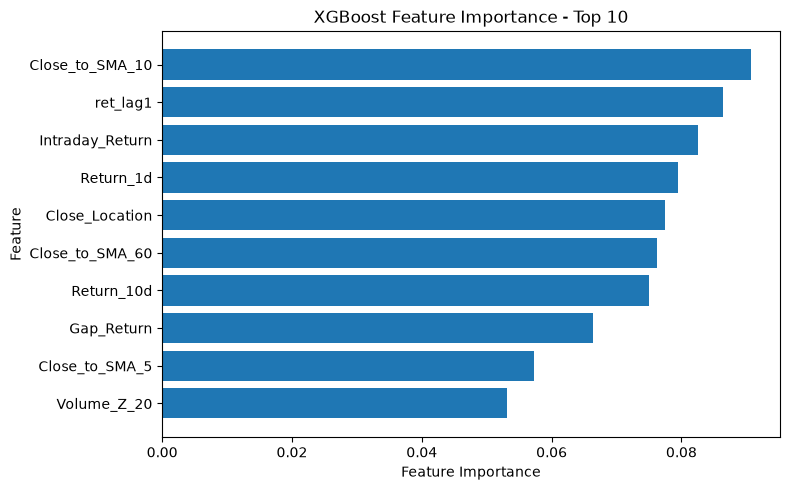

In [35]:
top_n = 10

plot_df = (
    importance_df
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance - Top 10")

plt.tight_layout()
plt.show()

In [13]:
##############################################

In [14]:
# ==========================================================================
# [배포용] 각자 방법론 + TDA 공통 스니펫  v2
#   출처: 금융_TDA_김소현_v2.ipynb §8 (셀 36~40) — 배선은 그대로, 모델 자리만 비움
#   변경점: ⑤변동성 대조군 추가 / test 평가 지원 / 스케일링·시드·회귀 지원
#
# ▶ evaluate() 는 이 스니펫의 정의를 쓰세요 (건너뛰지 말 것)
#   전처리 §14와 결과 컬럼이 완전히 같고, task 인자 하나만 추가된 버전입니다.
#   분류(소진·서연·소현)는 §14와 소수점까지 동일한 값이 나옵니다.
#   다영은 task="reg" 를 넘겨야 예측수익률을 0 기준으로 자릅니다 (run_matrix가 자동 처리).
#   ※ 평가 함수가 두 개 돌면 결과표를 나란히 못 붙이니, 자기 노트북의 옛 정의는
#     이 셀 아래에서 덮어쓰이도록 순서만 지켜 주세요.
# ==========================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score

In [15]:
# ==========================================================================
# 0. 준비 — 소현이 배포하는 파일 3개를 같은 폴더(또는 드라이브)에 두기
#
#    GSPC_arrays_20050101_20260101.npz          ← ★ 각자 전처리를 다시 돌리지 말고 이 파일을 쓰세요
#    tda_features_w50.csv     ← TDA 피처 8종
#    cross_index_features.csv ← 교차지수 피처 12종
#
#    ★ 이유: 지금 서연·다영 노트북은 END_DATE=2025-01-01 이라 test 구간이
#      2022-01-12~2024-12-31(745행)이고, 소진은 2026-01-01 이라 2022-11-14~
#      2025-12-30(783행)입니다. 서로 다른 구간이라 숫자를 나란히 못 놓습니다.
#      배포된 npz(END_DATE=2026-01-01)를 전원이 그대로 로드하면 이 문제가 사라집니다.
# ==========================================================================
NPZ_PATH   = "GSPC_arrays_20050101_20260101.npz "
TDA_PATH   = "tda_features_w50.csv"
CROSS_PATH = "cross_index_features.csv"

In [16]:
# ==========================================================================
# 1. 로드 (TDA 노트북 §8과 동일)
# ==========================================================================
d = np.load(NPZ_PATH, allow_pickle=True)
feat_cols = list(d["feature_columns"])

def restore(split):
    idx = pd.to_datetime(d[f"idx_{split}"])
    X = pd.DataFrame(d[f"X_{split}"], index=idx, columns=feat_cols)
    y = pd.Series(d[f"y_{split}_cls"], index=idx, name="y_updown").astype(int)
    yr = pd.Series(d[f"y_{split}_reg"], index=idx, name="y_reg")   # 회귀용(다영)
    return X, y, yr

X_train, y_train, yr_train = restore("train")
X_valid, y_valid, yr_valid = restore("valid")
X_test,  y_test,  yr_test  = restore("test")
print("npz 로드:", X_train.shape, X_valid.shape, X_test.shape, "| meta:", list(d["meta"]))

tda_features   = pd.read_csv(TDA_PATH,   encoding="utf-8-sig", index_col="Date", parse_dates=True)
cross_features = pd.read_csv(CROSS_PATH, encoding="utf-8-sig", index_col="Date", parse_dates=True)
tda_cols   = list(tda_features.columns)     # TDA_L1_H0 … TDA_L1_H1_std20 (8개)
cross_cols = list(cross_features.columns)   # X_exc1d_DJI … X_lead_RUT_1d (12개)
print("TDA", len(tda_cols), "| 교차지수", len(cross_cols))

npz 로드: (3654, 22) (782, 22) (783, 22) | meta: ['^GSPC', '2005-01-01', '2026-01-01', '1', 'True']
TDA 8 | 교차지수 12


In [17]:
# ==========================================================================
# 2. 팀 공통 evaluate() — 전처리 §14 + task 인자
#    임계값을 값 범위로 추측하지 않고 task 로 선언받습니다
# ==========================================================================

def evaluate(y_true_cls, score, name="model", task="clf",
             y_true_reg=None, pred_reg=None):
    score = np.asarray(score, dtype=float)
    y_true_cls = np.asarray(y_true_cls, dtype=int)
    thr = 0.5 if task == "clf" else 0.0
    y_pred = (score > thr).astype(int)
    out = {"model": name,
           "accuracy": accuracy_score(y_true_cls, y_pred),
           "f1": f1_score(y_true_cls, y_pred, zero_division=0),
           "roc_auc": roc_auc_score(y_true_cls, score),
           "n": len(y_true_cls)}
    if y_true_reg is not None and pred_reg is not None:
        from sklearn.metrics import mean_squared_error, r2_score
        out["rmse"] = float(np.sqrt(mean_squared_error(y_true_reg, pred_reg)))
        out["r2"] = float(r2_score(y_true_reg, pred_reg))
    return out

print("evaluate 정의 완료")

evaluate 정의 완료


In [18]:
# ==========================================================================
# 3. 병합 — 교차·TDA를 먼저 합친 뒤 join → 모든 실험이 '동일 표본'
# ==========================================================================
extra = cross_features.join(tda_features, how="inner")

def attach(X, y, yr):
    Xt = X.join(extra, how="inner").dropna(subset=cross_cols + tda_cols)
    return Xt, y.loc[Xt.index], yr.loc[Xt.index]

X_train_t, y_train_t, yr_train_t = attach(X_train, y_train, yr_train)
X_valid_t, y_valid_t, yr_valid_t = attach(X_valid, y_valid, yr_valid)
X_test_t,  y_test_t,  yr_test_t  = attach(X_test,  y_test,  yr_test)

print(f"train {len(X_train)} → {len(X_train_t)} (워밍업 제거, 앞부분만)")
print(f"valid {len(X_valid)} → {len(X_valid_t)} | test {len(X_test)} → {len(X_test_t)}")
assert len(X_valid_t) == len(X_valid) and len(X_test_t) == len(X_test), \
    "valid/test 행이 줄었음 — 날짜 정합 확인 필요!"

train 3654 → 3645 (워밍업 제거, 앞부분만)
valid 782 → 782 | test 783 → 783


In [19]:
# ==========================================================================
# 4. baseline 기준 — ★ 0.5 아님. train 다수 클래스를 항상 찍는 모델의 정확도
#    (사전적 기준: 학습 시점에 알 수 있는 정보만 사용)
#    현재 데이터에서는 valid 0.5409 / test 0.5568 이 나옵니다.
#    → 결과표에 accuracy 와 함께 baseline_acc, gap_pp 를 반드시 같이 적기
# ==========================================================================
maj = int(round(y_train_t.mean()))
BASE_ACC = {"valid": float((y_valid_t == maj).mean()),
            "test":  float((y_test_t == maj).mean())}
print("다수 클래스 baseline:", {k: round(v, 4) for k, v in BASE_ACC.items()})

다수 클래스 baseline: {'valid': 0.5409, 'test': 0.5568}


In [20]:
# ==========================================================================
# 5. 실험 정의 ①~⑤
#    ⑤는 4차 회의 이후 추가 — TDA norm 이 기존 변동성 피처와 같은 걸 재는지 가르는 대조군
# ==========================================================================
vol_cols = [c for c in feat_cols if c.startswith("Volatility_")]
h1_cols = ["TDA_L1_H1", "TDA_L2_H1", "TDA_PE_H1", "TDA_PE_H0", "TDA_L1_H1_diff1"]

EXPERIMENTS = {
    "① 베이스라인 (22)":    feat_cols,
    "② +교차지수 (22+12)":  feat_cols + cross_cols,
    "③ +TDA (22+8)":       feat_cols + tda_cols,
    "②+③ 전부 (22+20)":    feat_cols + cross_cols + tda_cols,
    "④ TDA만 (8)":         tda_cols,
    "④' 교차지수만 (12)":   cross_cols,
    "⑤ 변동성만 (4)":       vol_cols,        # ← ④와 짝지어 보기
    "⑥ TDA-H₁계열만 (5)":  h1_cols,
}

# 사전 진단: TDA 피처가 기존 변동성과 얼마나 겹치는가 (실험 돌리기 전 10분)
_diag = pd.concat([X_train_t[tda_cols], X_train_t[vol_cols]], axis=1).corr()
print("\nTDA × Volatility_20 상관:")
print(_diag.loc[tda_cols, "Volatility_20"].round(3).to_string())
print("→ 0.8 이상이면 ③이 ①을 못 이기는 게 당연. 그 자체가 보고할 결과입니다.")


TDA × Volatility_20 상관:
TDA_L1_H0          0.813
TDA_L1_H1          0.462
TDA_L2_H0          0.805
TDA_L2_H1          0.462
TDA_PE_H0         -0.075
TDA_PE_H1         -0.223
TDA_L1_H1_diff1    0.017
TDA_L1_H1_std20    0.643
→ 0.8 이상이면 ③이 ①을 못 이기는 게 당연. 그 자체가 보고할 결과입니다.


In [21]:
# ==========================================================================
# 6. 실험 매트릭스 실행 — make_model 은 "모델 만드는 함수를 받을 빈 자리"입니다. 실제 모델은
#    §8에서 run_matrix(xgb, ...) 처럼 넘기면 그때 채워집니다.
# ==========================================================================
from sklearn.preprocessing import StandardScaler

def run_matrix(make_model, name="model", split="valid",
               use_scaled=False, task="clf", seeds=(42,)):
    """
    make_model(seed) -> sklearn 호환 모델
    split : "valid" (기본, 튜닝·비교용) / "test" (최종 1회만)
    task  : "clf" 분류 / "reg" 회귀(Ridge·Lasso — 예측수익률 부호로 방향 판정)
    seeds : 여러 개 주면 예측값 평균 (Bagging처럼 시드 변동이 큰 모델용)
    """
    Xte_t = {"valid": X_valid_t, "test": X_test_t}[split]
    yte   = {"valid": y_valid_t, "test": y_test_t}[split]
    yr_te = {"valid": yr_valid_t, "test": yr_test_t}[split]
    ytr = yr_train_t if task == "reg" else y_train_t

    rows, probs = [], {}
    for exp_name, cols in EXPERIMENTS.items():
        Xtr, Xte = X_train_t[cols], Xte_t[cols]
        if use_scaled:
            sc = StandardScaler().fit(Xtr)          # ★ train 에만 fit
            Xtr = pd.DataFrame(sc.transform(Xtr), index=Xtr.index, columns=cols)
            Xte = pd.DataFrame(sc.transform(Xte), index=Xte.index, columns=cols)

        preds, seed_accs = [], []
        for s in seeds:
            m = make_model(s)
            m.fit(Xtr, ytr)
            if task == "clf" and hasattr(m, "predict_proba"):
                q = m.predict_proba(Xte)[:, 1]
            else:
                q = m.predict(Xte)
            preds.append(q)
            thr_q = 0.5 if task == "clf" else 0.0
            seed_accs.append(accuracy_score(yte, (q > thr_q).astype(int)))
        p = np.mean(preds, axis=0)
        probs[exp_name] = p

        if task == "reg":
            res = evaluate(yte, p, name=f"{name} {exp_name}", task=task,
                           y_true_reg=yr_te, pred_reg=p)
        else:
            res = evaluate(yte, p, name=f"{name} {exp_name}", task=task)
                # [추가] balanced_acc — 0.5 근처면 '한쪽 클래스로만 찍는 중'이라는 뜻
        thr_p = 0.5 if task == "clf" else 0.0
        res["balanced_acc"] = balanced_accuracy_score(
            np.asarray(yte, dtype=int), (p > thr_p).astype(int))
        res["n_feat"] = len(cols)
        res["split"] = split
        res["baseline_acc"] = BASE_ACC[split]
        res["gap_pp"] = (res["accuracy"] - BASE_ACC[split]) * 100
        if len(seeds) > 1:
            res["acc_std_seed"] = float(np.std(seed_accs, ddof=1))
        rows.append(res)

    df = pd.DataFrame(rows).round(4)
    front = ["model", "split", "n_feat", "accuracy", "baseline_acc", "gap_pp", "balanced_acc", "roc_auc", "f1", "n"]
    cols_order = front + [c for c in df.columns if c not in front]
    return df[cols_order], probs

In [22]:
# ==========================================================================
# 7. 핵심 비교의 ΔAUC 부트스트랩 CI (TDA 노트북 §8과 동일)
# ==========================================================================
def boot_auc_diff(y, p_a, p_b, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=int); p_a = np.asarray(p_a); p_b = np.asarray(p_b)
    diffs = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        diffs.append(roc_auc_score(y[i], p_b[i]) - roc_auc_score(y[i], p_a[i]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return float(np.mean(diffs)), float(lo), float(hi)


COMPARISONS = [
    ("① 베이스라인 (22)",   "② +교차지수 (22+12)"),
    ("① 베이스라인 (22)",   "③ +TDA (22+8)"),
    ("② +교차지수 (22+12)", "②+③ 전부 (22+20)"),
    ("⑤ 변동성만 (4)",      "④ TDA만 (8)"),        # ← TDA가 변동성을 넘어서는가
    ("④ TDA만 (8)",        "⑥ TDA-H₁계열만 (5)"),   # 희석 가설 검증
    ("⑤ 변동성만 (4)",      "⑥ TDA-H₁계열만 (5)"),   # H₁ vs 변동성 정면 비교
]

def compare_table(probs, split="valid"):
    y = {"valid": y_valid_t, "test": y_test_t}[split]
    rows = []
    for a, b in COMPARISONS:
        m, lo, hi = boot_auc_diff(y, probs[a], probs[b])
        rows.append({"비교": f"{a} → {b}", "ΔAUC": m,
                     "95% CI 하한": lo, "95% CI 상한": hi,
                     "0 포함": "예" if lo <= 0 <= hi else "아니오"})
    print("※ CI가 0을 포함하면 '이 표본에서 차이가 확인되지 않음'이 정확한 표현.")
    return pd.DataFrame(rows).round(4)

In [23]:
# ==========================================================================
# 8. 각자 모델 — 아래 자기 블록의 주석만 풀면 끝. 
# 모델을 lambda 로 만들어 run_matrix 의 첫 인자로 넘깁니다.
# ==========================================================================

# ── 소진 (Bagging / GBM) ────────────────────────────────────────────────
# from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
# from sklearn.tree import DecisionTreeClassifier
#
# bag = lambda s: BaggingClassifier(DecisionTreeClassifier(),
#                                   n_estimators=50, max_samples=0.8, random_state=s)
# gbm = lambda s: GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
#                                            max_depth=3, random_state=s)
# SEEDS = (0, 1, 2, 3, 4, 42, 100)          # 4차 회의에서 쓰신 7개 그대로
# res_bag, prob_bag = run_matrix(bag, "Bagging", seeds=SEEDS)
# res_gbm, prob_gbm = run_matrix(gbm, "GBM",     seeds=SEEDS)
# display(pd.concat([res_bag, res_gbm], ignore_index=True))
# display(compare_table(prob_gbm))
#
#  ▸ 시드 7개 평균으로 보는 이유: Bagging의 시드 표준편차가 0.0200인데
#    TDA 추가 효과는 커야 0.01~0.02 수준이라, 단일 실행으로는 판정 불가.
#    결과표의 acc_std_seed 컬럼을 gap_pp 와 반드시 같이 읽어 주세요.
#  ▸ baseline 은 0.5가 아니라 BASE_ACC(valid 0.5409 / test 0.5568)입니다.


# ── 서연 (XGBoost) ──────────────────────────────────────────────────────
from xgboost import XGBClassifier

xgb = lambda s: XGBClassifier(objective="binary:logistic",
                               n_estimators=6, max_depth=2, learning_rate=0.03,
                               min_child_weight=5, reg_lambda=5.0,
                               subsample=0.8, colsample_bytree=0.8,
                               tree_method="hist", random_state=s,
                               n_jobs=-1, verbosity=0)
res_xgb, prob_xgb = run_matrix(xgb, "XGBoost", seeds=(42, 202, 777, 1234, 20250815))
display(res_xgb); display(compare_table(prob_xgb))

#  ▸ 전처리 재실행 불필요 — 배포된 npz를 쓰면 END_DATE 2026-01-01로 자동 통일됩니다.
#    (기존 노트북 §1~§16을 건너뛰고 이 스니펫부터 실행)
#  ▸ 하이퍼파라미터는 ①에서 찾은 값을 ①~⑤에 그대로 고정합니다. 조합별 재탐색은
#    안 하는 쪽을 권합니다 — 1-SE 이내가 36/36이었으니 재탐색해도 같은 결론이 나오고,
#    실험마다 다른 설정을 쓰면 "TDA 효과"와 "튜닝 효과"가 섞입니다.
#  ▸ 여유가 되면 ③에서만 기존 TimeSeriesSplit 탐색을 한 번 더 돌려
#    1-SE 이내 조합이 36/36에서 줄어드는지 확인 → 줄면 "선택 가능한 신호가 생겼다"는 증거.


# ── 다영 (Ridge / Lasso) ────────────────────────────────────────────────
# from sklearn.linear_model import Ridge, Lasso
#
# ridge = lambda s: Ridge(alpha=1.0)
# lasso = lambda s: Lasso(alpha=1e-4, max_iter=10000)
# res_r, prob_r = run_matrix(ridge, "Ridge", use_scaled=True, task="reg")
# res_l, prob_l = run_matrix(lasso, "Lasso", use_scaled=True, task="reg")
# display(pd.concat([res_r, res_l], ignore_index=True))
#
#  ▸ task="reg" → 예측수익률의 부호로 방향을 판정하고, AUC는 예측수익률을 점수로 씁니다.
#    rmse·r2 컬럼도 같이 나오니 기존 회귀 지표 서사를 그대로 이어갈 수 있습니다.
#  ▸ Lasso 계수표를 꼭 같이 뽑아 주세요 (아래). 22개 중 20개를 0으로 만드셨는데,
#    TDA 피처가 0이 아닌 채로 살아남는지가 "선형이 못 잡는 정보가 TDA에 있는가"의
#    가장 직접적인 답입니다.
#
# sc = StandardScaler().fit(X_train_t[feat_cols + tda_cols])
# lz = Lasso(alpha=1e-4, max_iter=10000).fit(
#         sc.transform(X_train_t[feat_cols + tda_cols]), yr_train_t)
# coef = pd.Series(lz.coef_, index=feat_cols + tda_cols)
# print("0이 아닌 계수:", int((coef != 0).sum()), "/", len(coef))
# display(coef[coef != 0].sort_values(key=abs, ascending=False).round(6))


# ── 소현 (TDA, 참고) ────────────────────────────────────────────────────
#  본 노트북 §8이 원본이므로 별도 실행 불필요.
#  다만 §8의 EXPERIMENTS 에 "⑤ 변동성만"을 추가하고,
#  COMPARISONS 에 ("⑤ 변동성만", "④ TDA만")을 추가해 두면 팀 전체와 표가 맞습니다.


,model,split,n_feat,accuracy,baseline_acc,gap_pp,balanced_acc,roc_auc,f1,n,acc_std_seed
0,XGBoost ① 베이스라인 (22),valid,22,0.5409,0.5409,0.0,0.5,0.5372,0.7021,782,0.0
1,XGBoost ② +교차지수 (22+12),valid,34,0.5409,0.5409,0.0,0.5,0.5335,0.7021,782,0.0
2,XGBoost ③ +TDA (22+8),valid,30,0.5409,0.5409,0.0,0.5,0.5421,0.7021,782,0.0
3,XGBoost ②+③ 전부 (22+20),valid,42,0.5409,0.5409,0.0,0.5,0.5402,0.7021,782,0.0
4,XGBoost ④ TDA만 (8),valid,8,0.5409,0.5409,0.0,0.5,0.5017,0.7021,782,0.0
5,XGBoost ④' 교차지수만 (12),valid,12,0.5409,0.5409,0.0,0.5,0.5124,0.7021,782,0.0
6,XGBoost ⑤ 변동성만 (4),valid,4,0.5409,0.5409,0.0,0.5,0.5232,0.7021,782,0.0
7,XGBoost ⑥ TDA-H₁계열만 (5),valid,5,0.5409,0.5409,0.0,0.5,0.5421,0.7021,782,0.0


※ CI가 0을 포함하면 '이 표본에서 차이가 확인되지 않음'이 정확한 표현.


,비교,ΔAUC,95% CI 하한,95% CI 상한,0 포함
0,① 베이스라인 (22) → ② +교차지수 (22+12),-0.0040,-0.0232,0.0144,예
1,① 베이스라인 (22) → ③ +TDA (22+8),0.0045,-0.0159,0.0246,예
2,② +교차지수 (22+12) → ②+③ 전부 (22+20),0.0064,-0.0112,0.0237,예
3,⑤ 변동성만 (4) → ④ TDA만 (8),-0.0207,-0.0695,0.0300,예
4,④ TDA만 (8) → ⑥ TDA-H₁계열만 (5),0.0396,0.0043,0.0755,아니오
5,⑤ 변동성만 (4) → ⑥ TDA-H₁계열만 (5),0.0189,-0.0343,0.0756,예


In [12]:
# ==========================================================================
# 9. 제출 형식 (5차 회의 8/22)
#    - 위 결과표를 CSV로 저장해서 노션에 올려 주세요. 파일명: matrix_{이름}.csv
#    - split="valid" 결과를 기본으로 냅니다. test는 방향 확정 후 마지막에 1회만.
# ==========================================================================
# res_gbm.to_csv("matrix_소진.csv", index=False, encoding="utf-8-sig")